# 10-Year Bond Yield Prediction using Stacked LSTM

## Overview
This notebook implements a 3-layer stacked LSTM model to predict the **future 5-day changes** (1st order difference) of the 10-year Chinese government bond yield based on the past **60 days** of history.

## Data Processing
1. **Load Data**: Read the CSV file, cleaning metadata and footers.
2. **Differencing**: Compute the 1st order difference to make the time series stationary.
3. **Normalization**: Scale the data to [-1, 1] using MinMaxScaler.
4. **Sequence Creation**: Create sliding window samples (Input: 60 days, Output: 5 days).
5. **Splitting**:
    - Train+Val: First 80%
    - Test: Last 20%
    - Train: First 90% of Train+Val
    - Val: Last 10% of Train+Val


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline

2025-12-17 03:24:48.247146: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 03:24:48.330721: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2025-12-17 03:24:50.507750: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loaded 1238 rows.
        Date   Yield
0 2021-01-04  3.1780
1 2021-01-05  3.1305
2 2021-01-06  3.1256
3 2021-01-07  3.1256
4 2021-01-08  3.1456
           Date   Yield
1233 2025-12-10  1.8447
1234 2025-12-11  1.8404
1235 2025-12-12  1.8396
1236 2025-12-15  1.8488
1237 2025-12-16  1.8458


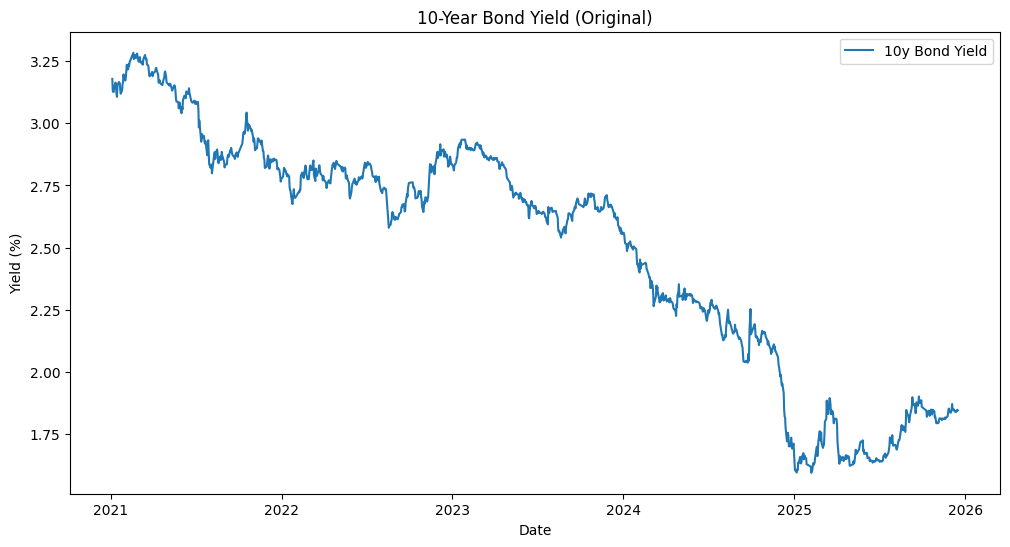

In [2]:
def load_data(filepath):
    # Skip metadata rows (first 8 lines) and handle GBK encoding
    try:
        df = pd.read_csv(filepath, skiprows=8, header=None, encoding='gbk', names=['Date', 'Yield'])
    except Exception as e:
        print(f"Error reading csv: {e}")
        return None

    # Parse dates and sort
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df = df.sort_values('Date')
    
    # Parse Yield
    df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')
    df = df.dropna(subset=['Yield'])
    
    return df.reset_index(drop=True)

filepath = '中债国债到期收益率_10年.csv'
# Note: Ensure the csv file is in the same directory
df = load_data(filepath)

print(f"Loaded {len(df)} rows.")
print(df.head())
print(df.tail())

# Plot original yield
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Yield'], label='10y Bond Yield')
plt.title('10-Year Bond Yield (Original)')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.show()

In [3]:
def preprocess_data(df, window_size=60, horizon=5):
    # 1. First Order Difference
    df['Yield_Diff'] = df['Yield'].diff()
    df_diff = df.dropna().reset_index(drop=True)
    
    # 2. Normalize to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    # Fit on the whole dataset as per requirements
    data_scaled = scaler.fit_transform(df_diff[['Yield_Diff']])
    
    # 3. Create Sequences
    X, y = [], []
    N = len(data_scaled)
    # i goes from 0 to N - window - horizon
    for i in range(N - window_size - horizon + 1):
        x_seq = data_scaled[i : i + window_size]
        y_seq = data_scaled[i + window_size : i + window_size + horizon]
        X.append(x_seq)
        y.append(y_seq)
        
    X = np.array(X)
    y = np.array(y)
    # Flatten y from (Samples, 5, 1) to (Samples, 5)
    y = y.reshape(y.shape[0], horizon)
    
    return X, y, scaler, df_diff

X, y, scaler, df_diff = preprocess_data(df)
print(f"Generated Samples: {len(X)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Generated Samples: 1173
X shape: (1173, 60, 1), y shape: (1173, 5)


In [4]:
# Split Ratios
# Train+Val: 80%, Test: 20%
# Train: 90% of (Train+Val), Val: 10% of (Train+Val)

total_samples = len(X)
train_val_split_idx = int(total_samples * 0.8)

X_train_val = X[:train_val_split_idx]
y_train_val = y[:train_val_split_idx]

X_test = X[train_val_split_idx:]
y_test = y[train_val_split_idx:]

train_split_idx = int(len(X_train_val) * 0.9)
X_train = X_train_val[:train_split_idx]
y_train = y_train_val[:train_split_idx]

X_val = X_train_val[train_split_idx:]
y_val = y_train_val[train_split_idx:]

print(f"Training Set: {X_train.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Test Set: {X_test.shape}")

Training Set: (844, 60, 1)
Validation Set: (94, 60, 1)
Test Set: (235, 60, 1)


In [5]:
def build_model(input_shape):
    model = Sequential()
    
    model.add(Input(shape=input_shape))
    
    # Layer 1: LSTM 128
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Layer 2: LSTM 64
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Layer 3: LSTM 32
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Dense Layers
    model.add(Dense(32, activation='relu'))
    model.add(Dense(5)) # Output: 5 days horizon
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.summary()

2025-12-17 03:24:52.016930: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,605 (506.27 KB)

 Trainable params: 129,605 (506.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


 1/27 ━━━━━━━━━━━━━━━━━━━━ 2:23 6s/step - loss: 0.0360 - mae: 0.1419

 2/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0336 - mae: 0.1369

 3/27 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0333 - mae: 0.1361

 4/27 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0330 - mae: 0.1356

...

24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0314 - mae: 0.1310

25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0313 - mae: 0.1309

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0313 - mae: 0.1308

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0313 - mae: 0.1307

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0302 - mae: 0.1276 - val_loss: 0.0672 - val_mae: 0.1781


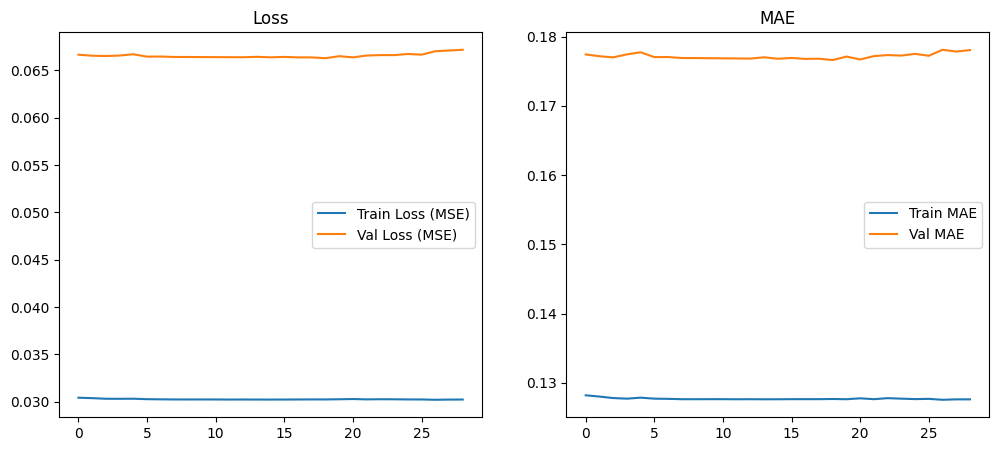

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend()
plt.title('MAE')
plt.show()

In [7]:
# Predict on Test Set
y_pred_scaled = model.predict(X_test)

# Metrics on Scaled Data
mse = mean_squared_error(y_test, y_pred_scaled)
mae = mean_absolute_error(y_test, y_pred_scaled)
print(f"Test MSE (Scaled): {mse:.6f}")
print(f"Test MAE (Scaled): {mae:.6f}")

# Inverse Transform to get Real Differences
# We reshape to (N, 1) to use the scalar, then reshape back
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)

mse_real = mean_squared_error(y_test_inv, y_pred_inv)
mae_real = mean_absolute_error(y_test_inv, y_pred_inv)
print("-" * 30)
print(f"Test MSE (Real Difference): {mse_real:.6f}")
print(f"Test MAE (Real Difference): {mae_real:.6f}")

1/8 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


Test MSE (Scaled): 0.038556
Test MAE (Scaled): 0.137135
------------------------------
Test MSE (Real Difference): 0.000392
Test MAE (Real Difference): 0.013823


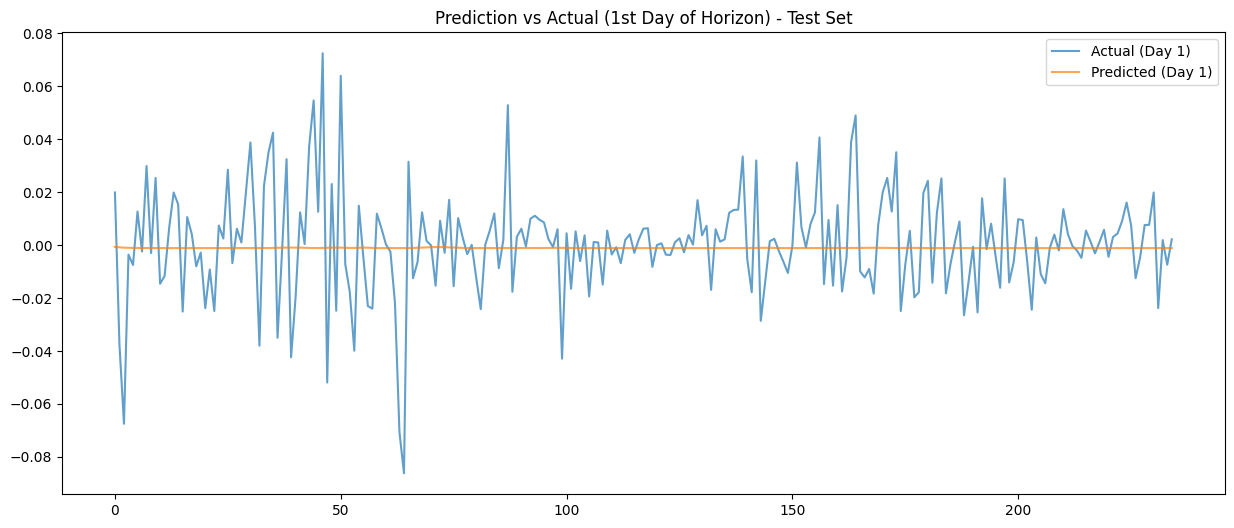

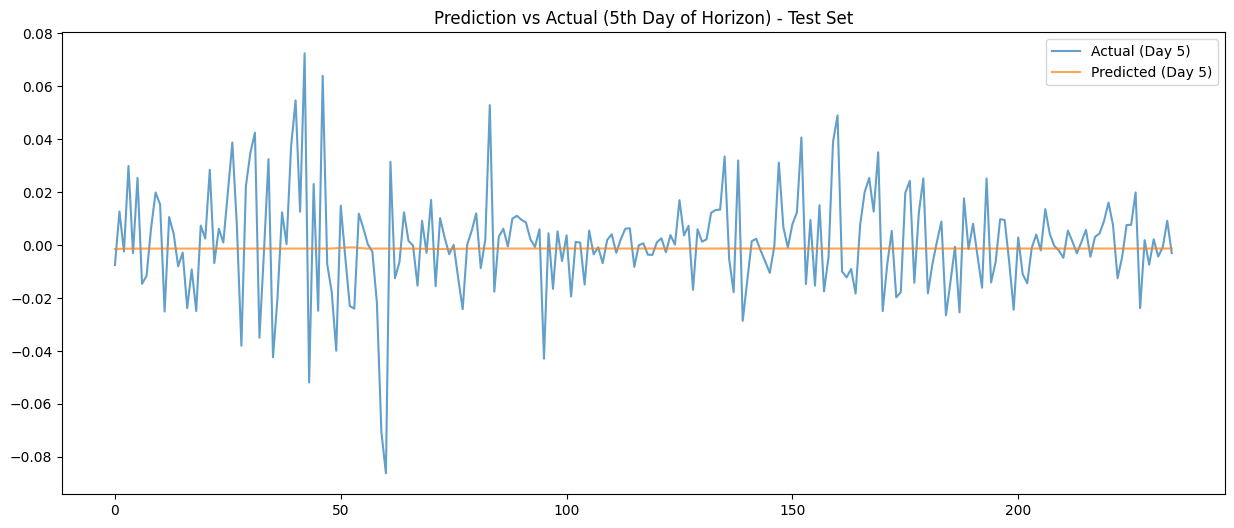

In [8]:
# Plot Prediction vs Actual for Day 1 of the Horizon
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[:, 0], label='Actual (Day 1)', alpha=0.7)
plt.plot(y_pred_inv[:, 0], label='Predicted (Day 1)', alpha=0.7)
plt.title('Prediction vs Actual (1st Day of Horizon) - Test Set')
plt.legend()
plt.show()

# Plot for Day 5 of the Horizon
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[:, 4], label='Actual (Day 5)', alpha=0.7)
plt.plot(y_pred_inv[:, 4], label='Predicted (Day 5)', alpha=0.7)
plt.title('Prediction vs Actual (5th Day of Horizon) - Test Set')
plt.legend()
plt.show()